
SLEEP ANALYZER - Complete Edition with Stable-Period HRV
Step 1: Load Raw Data
✓ dailies.csv: 6,047 records
✓ sleeps.csv: 3,976 records

Reading heart rate data...
✓ dailies_heartrate.csv: 20,772,772 records

Step 2: Process Sleep Data
✓ Filtered sleep records: 446 (Removed 769)
✓ Deep sleep ratio: 11.7% ± 6.2%

Step 3: Extract Core Exercise Features (Stable HRV: middle 50% of exercise)
✓ Exercise days: 1725
✓ Base features: 8
✓ Stable-period HRV features: 7
✓ Total features: 17

Step 4: Merge Data + Minimal Feature Engineering
✓ Merged records: 154 (Filtered 1)
✓ Gap range: 0.0h ~ 15.9h

✓ Stable-period HRV Features Summary:
   hrv_stable_std: 8.91 ± 2.63
   hrv_stable_cv: 0.10 ± 0.03
   hrv_stable_rmssd: 2.77 ± 0.93
   hrv_stable_range: 41.06 ± 15.15

Exploratory Data Analysis
✓ Saved: ./巨量資料概論/outputs/exploratory_analysis.png


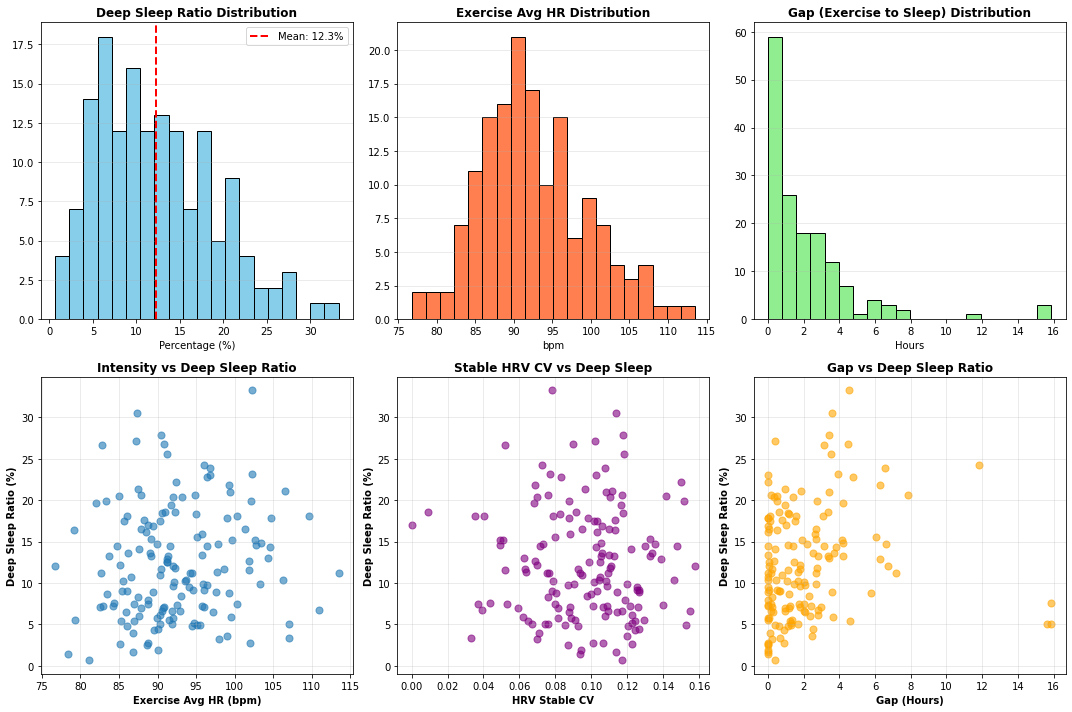


Correlation with Deep Sleep Ratio:
deepSleepRatio            1.000000
ex_distance_km            0.232455
gap_hours                 0.152797
ex_hr_mean                0.110362
hrv_stable_variability    0.060173
hrv_stable_range          0.039877
ex_duration_minutes      -0.004178
hrv_stable_std           -0.017320
vigorous_ratio           -0.040757
hrv_stable_cv            -0.054050
hrv_stable_rmssd         -0.071029
Name: deepSleepRatio, dtype: float64

Analysis: Exercise Intensity vs Sleep Quality
F-statistic: 0.2483, P-value: 0.7805

Deep Sleep Ratio by Intensity Group (%):
                         mean       std  count
intensity_group                               
Low Intensity       11.843889  6.770254     52
Moderate Intensity  12.778099  6.564465     51
High Intensity      12.265985  6.866872     51

• Conclusion: No statistical significance (p = 0.7805)
✓ Saved: ./巨量資料概論/outputs/intensity_analysis.png


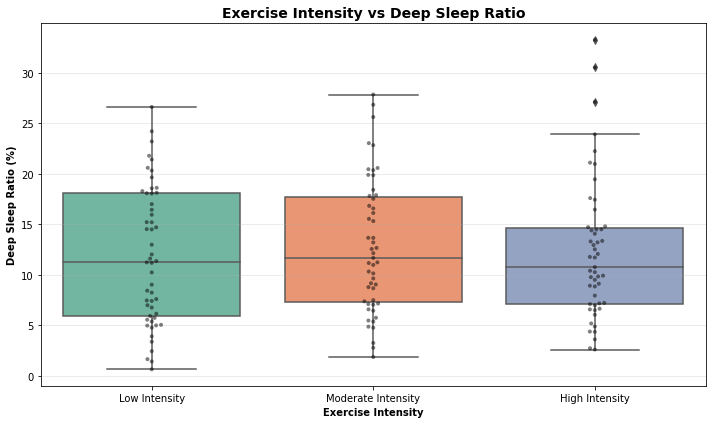


Analysis: Optimal Exercise Timing

Deep Sleep Ratio Statistics by Gap (%):
          deepSleepRatio                
                    mean       std count
gap_group                               
0-2h           11.363934  5.848275    72
2-4h           13.543562  6.926060    37
4-6h           17.774973  8.813314     9
6-8h           16.605072  4.833116     8
>8h            10.464308  9.242868     4

✓ Best Gap: 4-6h (Avg 17.8%)
✓ Saved: ./巨量資料概論/outputs/timing_analysis.png


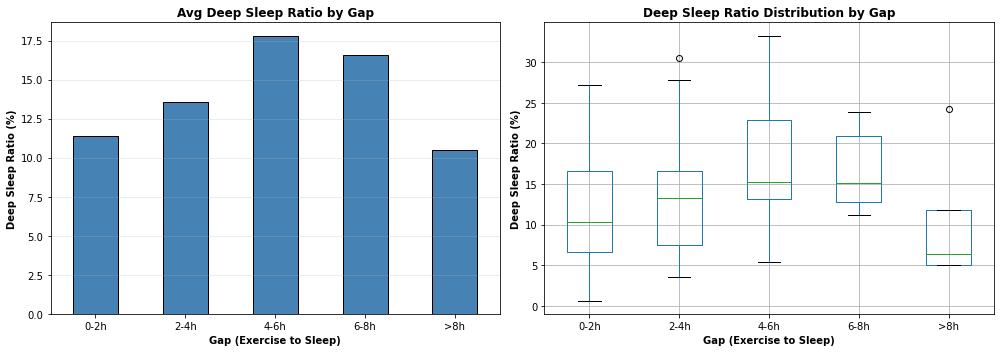


Simple Prediction Model (Exercise Features + Stable HRV)

Model Performance:
  R² Score: 0.6009
  MAE: 3.51%
  RMSE: 4.22%

Feature Importance Ranking:
  1. gap_hours (Exercise): 0.2902
  2. ex_distance_km (Exercise): 0.2276
  3. ex_duration_minutes (Exercise): 0.0827
  4. hrv_stable_variability (Stable HRV): 0.0591
  5. vigorous_duration_minutes (Exercise): 0.0501
  6. hrv_stable_rmssd (Stable HRV): 0.0500
  7. hrv_stable_range (Stable HRV): 0.0474
  8. hrv_stable_mean (Stable HRV): 0.0469
  9. hrv_stable_cv (Stable HRV): 0.0460
  10. ex_hr_std (Exercise): 0.0389
  11. hrv_stable_std (Stable HRV): 0.0313
  12. ex_hr_mean (Exercise): 0.0298
✓ Saved: ./巨量資料概論/outputs/simple_model.png


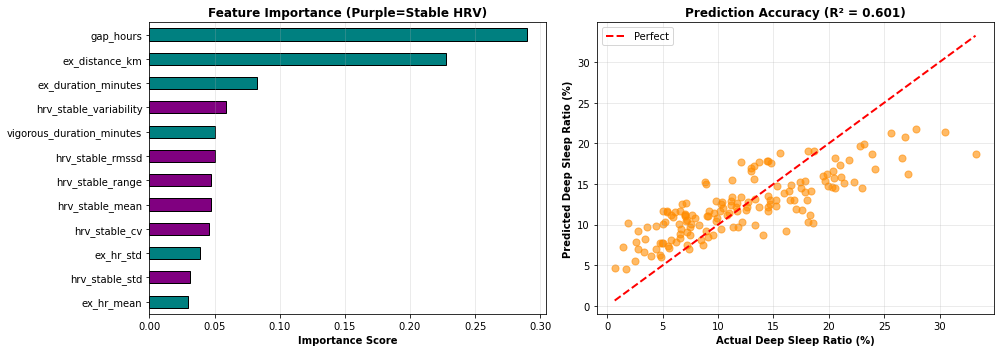


Personalized Exercise Recommendations

Top 5 Exercise Configs for Deep Sleep Ratio:

#1 Deep Sleep Ratio: 33.3%
  - Avg HR: 102 bpm
  - Distance: 0.2 km
  - Duration: 132 min
  - Gap: 4.5 hours
  - HRV Stable CV: 0.0782
  - HRV Stable RMSSD: 1.87 bpm

#2 Deep Sleep Ratio: 30.5%
  - Avg HR: 87 bpm
  - Distance: 6.2 km
  - Duration: 38 min
  - Gap: 3.6 hours
  - HRV Stable CV: 0.1135
  - HRV Stable RMSSD: 3.13 bpm

#3 Deep Sleep Ratio: 27.8%
  - Avg HR: 90 bpm
  - Distance: 5.9 km
  - Duration: 37 min
  - Gap: 3.4 hours
  - HRV Stable CV: 0.1176
  - HRV Stable RMSSD: 3.12 bpm

#4 Deep Sleep Ratio: 27.1%
  - Avg HR: 87 bpm
  - Distance: 7.0 km
  - Duration: 38 min
  - Gap: 0.4 hours
  - HRV Stable CV: 0.1022
  - HRV Stable RMSSD: 2.89 bpm

#5 Deep Sleep Ratio: 26.8%
  - Avg HR: 91 bpm
  - Distance: 2.2 km
  - Duration: 29 min
  - Gap: 4.5 hours
  - HRV Stable CV: 0.0898
  - HRV Stable RMSSD: 2.71 bpm

------------------------------------------------------------
Recommended Parameter Rang

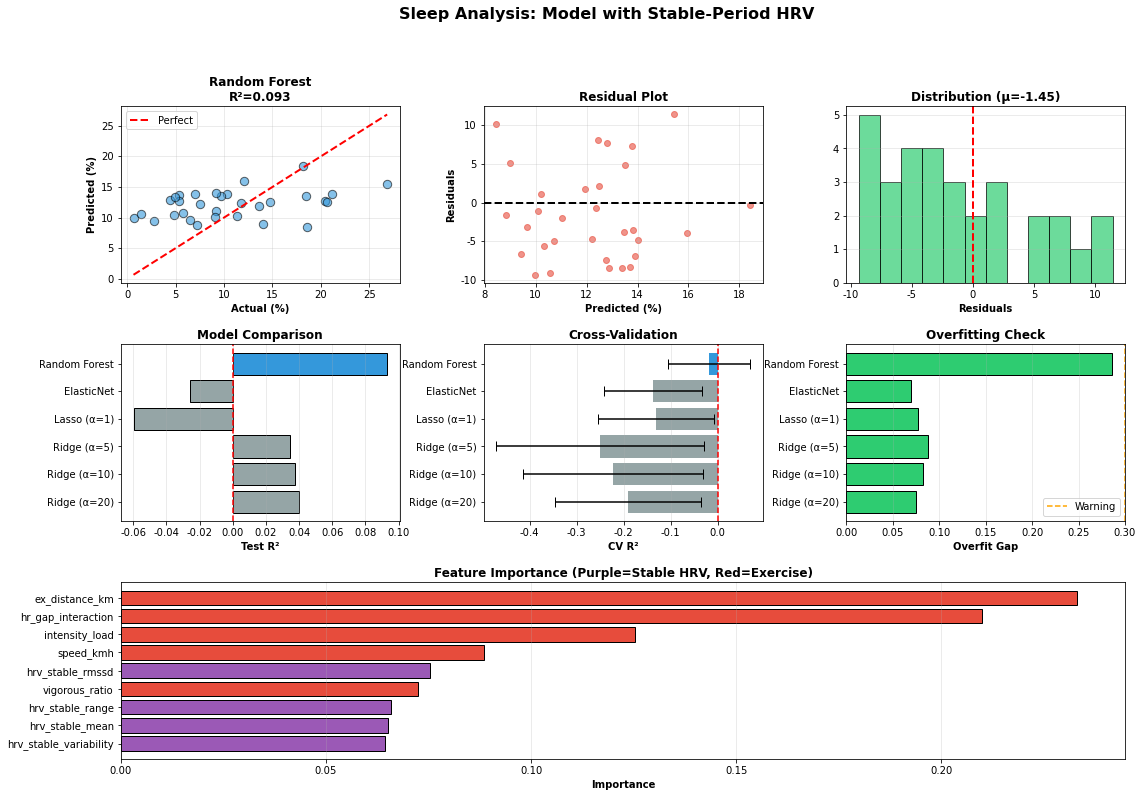

In [1]:
"""
睡眠分析器 - 完整版（穩定期HRV）
包含探索性分析、強度分析、時間分析、簡單模型、個性化建議和穩定期心率變異分析
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os
from scipy import stats

warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import f_regression, mutual_info_regression

# 字體設定
import matplotlib.font_manager as fm
plt.rcParams['axes.unicode_minus'] = False
candidates = ['Arial', 'Helvetica', 'Microsoft JhengHei', 'SimHei', 'Arial Unicode MS', 'Heiti TC']
for font in candidates:
    if font in [f.name for f in fm.fontManager.ttflist]:
        plt.rcParams['font.sans-serif'] = [font]
        break


class SleepAnalyzer:
    """睡眠分析器 - 完整版（穩定期HRV）"""
    
    def __init__(self, data_dir='./巨量資料概論', output_dir=None):
        self.data_dir = data_dir
        self.output_dir = os.path.join(data_dir, 'outputs') if output_dir is None else output_dir
        self.dailies = None
        self.sleeps = None
        self.heartrate_detail = None
        self.df_final = None
        
    def load_data(self, verbose=True):
        """載入數據"""
        if verbose:
            print("=" * 80)
            print("Step 1: Load Raw Data")
            print("=" * 80)
        
        try:
            self.dailies = pd.read_csv(f'{self.data_dir}/dailies.csv')
            self.sleeps = pd.read_csv(f'{self.data_dir}/sleeps.csv')
            
            if verbose:
                print(f"✓ dailies.csv: {len(self.dailies):,} records")
                print(f"✓ sleeps.csv: {len(self.sleeps):,} records")
            
            if verbose:
                print("\nReading heart rate data...")
            self.heartrate_detail = pd.read_csv(f'{self.data_dir}/dailies_heartrate.csv')
            
            if verbose:
                print(f"✓ dailies_heartrate.csv: {len(self.heartrate_detail):,} records")
            
            return True
            
        except FileNotFoundError as e:
            print(f"❌ Error: {e}")
            return False
    
    def process_sleep_data(self, verbose=True):
        """處理睡眠數據"""
        if verbose:
            print("\n" + "=" * 80)
            print("Step 2: Process Sleep Data")
            print("=" * 80)
        
        rename_map = {}
        for col in self.sleeps.columns:
            if 'startTime' in col and 'Seconds' in col and 'Offset' not in col:
                rename_map[col] = 'startTimeInSeconds'
            if 'deepSleep' in col and 'Duration' in col:
                rename_map[col] = 'deepSleepDurationInSeconds'
        if rename_map:
            self.sleeps.rename(columns=rename_map, inplace=True)
        
        self.sleeps['sleep_start_dt'] = pd.to_datetime(
            self.sleeps['startTimeInSeconds'], unit='s'
        )
        
        def get_activity_date(dt):
            local_dt = dt + timedelta(hours=8)
            if local_dt.hour < 12:
                return (local_dt - timedelta(days=1)).date()
            else:
                return local_dt.date()
        
        self.sleeps['activity_date'] = self.sleeps['sleep_start_dt'].apply(get_activity_date)
        self.sleeps['activity_date'] = pd.to_datetime(self.sleeps['activity_date'])
        
        sleep_agg = self.sleeps.groupby(['_userId', 'activity_date']).agg({
            'startTimeInSeconds': 'min',
            'deepSleepDurationInSeconds': 'sum',
            'durationInSeconds': 'sum',
        }).reset_index()
        
        sleep_agg['deepSleepMinutes'] = sleep_agg['deepSleepDurationInSeconds'] / 60
        sleep_agg['totalSleepMinutes'] = sleep_agg['durationInSeconds'] / 60
        
        sleep_agg['deepSleepRatio'] = (sleep_agg['deepSleepMinutes'] / 
                                       sleep_agg['totalSleepMinutes'] * 100)
        
        before_filter = len(sleep_agg)
        sleep_agg = sleep_agg[
            (sleep_agg['deepSleepMinutes'] >= 10) &
            (sleep_agg['deepSleepMinutes'] <= 180) &
            (sleep_agg['deepSleepRatio'] <= 40)
        ]
        
        if verbose:
            print(f"✓ Filtered sleep records: {len(sleep_agg)} (Removed {before_filter - len(sleep_agg)})")
            print(f"✓ Deep sleep ratio: {sleep_agg['deepSleepRatio'].mean():.1f}% ± {sleep_agg['deepSleepRatio'].std():.1f}%")
        
        return sleep_agg
    
    def calculate_hrv_features_stable_period(self, hr_series, 
                                             exclude_start_pct=0.2, 
                                             exclude_end_pct=0.2):
        """
        計算穩定期的心率變異特徵（排除開始和結束的不穩定期）
        
        參數:
            hr_series: 心率序列（pandas Series）
            exclude_start_pct: 排除開始的百分比（預設20%）
            exclude_end_pct: 排除結束的百分比（預設20%）
        
        返回:
            dict: 包含6個穩定期HRV特徵的字典
        """
        if len(hr_series) < 30:
            return None
        
        hr_values = hr_series.values
        total_len = len(hr_values)
        
        # 只取中間的數據（排除前後不穩定期）
        start_idx = int(total_len * exclude_start_pct)
        end_idx = int(total_len * (1 - exclude_end_pct))
        
        if end_idx - start_idx < 10:  # 如果太短就用全部
            stable_hr = hr_values
        else:
            stable_hr = hr_values[start_idx:end_idx]
        
        # 1. 標準差（整體變異）
        hrv_stable_std = np.std(stable_hr)
        
        # 2. 變異係數（標準化的變異）
        hrv_stable_mean = np.mean(stable_hr)
        hrv_stable_cv = hrv_stable_std / hrv_stable_mean if hrv_stable_mean > 0 else 0
        
        # 3. 連續差值的均方根（RMSSD）
        stable_hr_diffs = np.diff(stable_hr)
        hrv_stable_rmssd = np.sqrt(np.mean(stable_hr_diffs ** 2)) if len(stable_hr_diffs) > 0 else 0
        
        # 4. 心率範圍
        hrv_stable_range = np.max(stable_hr) - np.min(stable_hr)
        
        # 5. 穩定度指標（變化方向改變的頻率，越高越不穩定）
        if len(stable_hr_diffs) > 0:
            sign_changes = np.sum(np.diff(np.sign(stable_hr_diffs)) != 0)
            hrv_stable_variability = sign_changes / len(stable_hr_diffs)  # 0-1之間
        else:
            hrv_stable_variability = 0
        
        
        return {
            'hrv_stable_std': hrv_stable_std,              # 標準差
            'hrv_stable_cv': hrv_stable_cv,                # 變異係數
            'hrv_stable_rmssd': hrv_stable_rmssd,          # 連續差值均方根
            'hrv_stable_range': hrv_stable_range,          # 心率範圍
            'hrv_stable_variability': hrv_stable_variability,  # 波動頻率
            'hrv_stable_mean': hrv_stable_mean             # 穩定期平均心率
        }
    
    def process_exercise_data(self, exclude_start_pct=0.2, exclude_end_pct=0.2, verbose=True):
        """
        提取核心運動特徵（包含穩定期心率變異）
        
        參數:
            exclude_start_pct: 排除開始的百分比
            exclude_end_pct: 排除結束的百分比
        """
        if verbose:
            print("\n" + "=" * 80)
            stable_pct = int((1 - exclude_start_pct - exclude_end_pct) * 100)
            print(f"Step 3: Extract Core Exercise Features (Stable HRV: middle {stable_pct}% of exercise)")
            print("=" * 80)
        
        self.dailies['date'] = pd.to_datetime(self.dailies['date'], errors='coerce')
        self.dailies = self.dailies.dropna(subset=['date'])
        self.dailies = self.dailies[
            (self.dailies['date'] >= '2010-01-01') & 
            (self.dailies['date'] <= '2030-12-31')
        ]
        
        daily_info = self.dailies[[
            '_userId', 'summaryId', 'date', 'distanceInMeters',
            'restingHeartRateInBeatsPerMinute', 'startTimeInSeconds'
        ]].copy()
        
        merged_hr = pd.merge(
            self.heartrate_detail, daily_info, 
            on='summaryId', how='inner', suffixes=('', '_daily')
        )
        
        if '_userId_daily' in merged_hr.columns:
            merged_hr.drop('_userId_daily', axis=1, inplace=True)
        
        if merged_hr['timeseconds'].iloc[0] < 1000000000:
            merged_hr['absolute_time'] = (merged_hr['startTimeInSeconds'] + 
                                         merged_hr['timeseconds'])
        else:
            merged_hr['absolute_time'] = merged_hr['timeseconds']
        
        exercise_records = []
        
        for (uid, date), group in merged_hr.groupby(['_userId', 'date']):
            resting_hr = group['restingHeartRateInBeatsPerMinute'].iloc[0]
            if pd.isna(resting_hr):
                resting_hr = 60
            
            moderate_threshold = resting_hr + 20
            vigorous_threshold = resting_hr + 40
            
            moderate_zone = group[group['HeartRate'] > moderate_threshold]
            vigorous_zone = group[group['HeartRate'] > vigorous_threshold]
            
            if len(moderate_zone) >= 10:
                distance = group['distanceInMeters'].iloc[0] if 'distanceInMeters' in group.columns else 0
                
                # 基本特徵
                record = {
                    '_userId': uid,
                    'date': date,
                    'ex_hr_mean': moderate_zone['HeartRate'].mean(),
                    'ex_hr_std': moderate_zone['HeartRate'].std(),
                    'ex_duration_minutes': len(moderate_zone) / 60,
                    'vigorous_duration_minutes': len(vigorous_zone) / 60,
                    'ex_distance_km': distance / 1000,
                    'resting_hr': resting_hr,
                    'last_ex_time': moderate_zone['absolute_time'].max(),
                }
                
                # 計算穩定期HRV特徵
                hrv_features = self.calculate_hrv_features_stable_period(
                    moderate_zone['HeartRate'],
                    exclude_start_pct=exclude_start_pct,
                    exclude_end_pct=exclude_end_pct
                )
                
                if hrv_features:
                    record.update(hrv_features)
                    
                    # 計算相對於靜止心率的HRV指標
                    record['hrv_stable_elevation'] = hrv_features['hrv_stable_mean'] - resting_hr
                
                exercise_records.append(record)
        
        ex_df = pd.DataFrame(exercise_records)
        
        if len(ex_df) > 0:
            # 衍生特徵
            ex_df['hr_elevation'] = ex_df['ex_hr_mean'] - ex_df['resting_hr']
            ex_df['vigorous_ratio'] = ex_df['vigorous_duration_minutes'] / (ex_df['ex_duration_minutes'] + 0.01)
            ex_df['speed_kmh'] = ex_df['ex_distance_km'] / (ex_df['ex_duration_minutes'] / 60 + 0.01)
            ex_df['intensity_load'] = ex_df['ex_hr_mean'] * ex_df['ex_duration_minutes']
        
        if verbose:
            print(f"✓ Exercise days: {len(ex_df)}")
            base_features = 8
            hrv_count = len([c for c in ex_df.columns if c.startswith('hrv_')])
            print(f"✓ Base features: {base_features}")
            print(f"✓ Stable-period HRV features: {hrv_count}")
            print(f"✓ Total features: {len(ex_df.columns) - 3}")
        
        return ex_df
    
    def prepare_unified_dataset(self, sleep_agg, ex_df, verbose=True):
        """合併數據"""
        if verbose:
            print("\n" + "=" * 80)
            print("Step 4: Merge Data + Minimal Feature Engineering")
            print("=" * 80)
        
        sleep_agg['activity_date'] = pd.to_datetime(sleep_agg['activity_date'])
        ex_df['date'] = pd.to_datetime(ex_df['date'], errors='coerce')
        ex_df = ex_df.dropna(subset=['date'])
        ex_df = ex_df[
            (ex_df['date'] >= '2010-01-01') & 
            (ex_df['date'] <= '2030-12-31')
        ]
        
        final_df = pd.merge(
            sleep_agg, ex_df,
            left_on=['_userId', 'activity_date'],
            right_on=['_userId', 'date'],
            how='inner'
        )
        
        if final_df.empty:
            if verbose:
                print("❌ No data after merge")
            return pd.DataFrame()
        
        final_df['gap_hours'] = (final_df['startTimeInSeconds'] - 
                                 final_df['last_ex_time']) / 3600
        
        before = len(final_df)
        final_df = final_df[
            (final_df['gap_hours'] >= -2) & 
            (final_df['gap_hours'] <= 24)
        ]
        final_df.loc[final_df['gap_hours'] < 0, 'gap_hours'] = 0
        final_df = final_df.dropna()
        
        final_df['gap_squared'] = final_df['gap_hours'] ** 2
        final_df['hr_gap_interaction'] = final_df['ex_hr_mean'] * final_df['gap_hours']
        
        if verbose:
            print(f"✓ Merged records: {len(final_df)} (Filtered {before - len(final_df)})")
            print(f"✓ Gap range: {final_df['gap_hours'].min():.1f}h ~ {final_df['gap_hours'].max():.1f}h")
            
            # 顯示HRV特徵統計
            hrv_cols = [c for c in final_df.columns if c.startswith('hrv_')]
            if hrv_cols:
                print(f"\n✓ Stable-period HRV Features Summary:")
                for col in hrv_cols[:4]:  # 顯示前4個
                    print(f"   {col}: {final_df[col].mean():.2f} ± {final_df[col].std():.2f}")
        
        self.df_final = final_df
        return final_df
    
    def exploratory_analysis(self, verbose=True):
        """探索性數據分析（使用 deepSleepRatio）"""
        if self.df_final is None or len(self.df_final) == 0:
            print("❌ No data available for analysis")
            return
        
        if verbose:
            print("\n" + "=" * 80)
            print("Exploratory Data Analysis")
            print("=" * 80)
        
        df = self.df_final
        
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # 1. Deep Sleep Ratio Distribution
        axes[0, 0].hist(df['deepSleepRatio'], bins=20, color='skyblue', edgecolor='black')
        axes[0, 0].set_title('Deep Sleep Ratio Distribution', fontweight='bold')
        axes[0, 0].set_xlabel('Percentage (%)')
        axes[0, 0].axvline(df['deepSleepRatio'].mean(), color='red', linestyle='--', 
                          lw=2, label=f'Mean: {df["deepSleepRatio"].mean():.1f}%')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3, axis='y')
        
        # 2. Exercise HR Distribution
        axes[0, 1].hist(df['ex_hr_mean'], bins=20, color='coral', edgecolor='black')
        axes[0, 1].set_title('Exercise Avg HR Distribution', fontweight='bold')
        axes[0, 1].set_xlabel('bpm')
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        
        # 3. Gap Distribution
        axes[0, 2].hist(df['gap_hours'], bins=20, color='lightgreen', edgecolor='black')
        axes[0, 2].set_title('Gap (Exercise to Sleep) Distribution', fontweight='bold')
        axes[0, 2].set_xlabel('Hours')
        axes[0, 2].grid(True, alpha=0.3, axis='y')
        
        # 4. HR vs Deep Sleep Ratio
        axes[1, 0].scatter(df['ex_hr_mean'], df['deepSleepRatio'], alpha=0.6, s=50)
        axes[1, 0].set_xlabel('Exercise Avg HR (bpm)', fontweight='bold')
        axes[1, 0].set_ylabel('Deep Sleep Ratio (%)', fontweight='bold')
        axes[1, 0].set_title('Intensity vs Deep Sleep Ratio', fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 5. Stable HRV vs Deep Sleep Ratio
        if 'hrv_stable_cv' in df.columns:
            axes[1, 1].scatter(df['hrv_stable_cv'], df['deepSleepRatio'], 
                              alpha=0.6, s=50, color='purple')
            axes[1, 1].set_xlabel('HRV Stable CV', fontweight='bold')
            axes[1, 1].set_ylabel('Deep Sleep Ratio (%)', fontweight='bold')
            axes[1, 1].set_title('Stable HRV CV vs Deep Sleep', fontweight='bold')
            axes[1, 1].grid(True, alpha=0.3)
        else:
            axes[1, 1].scatter(df['ex_distance_km'], df['deepSleepRatio'], 
                              alpha=0.6, s=50, color='purple')
            axes[1, 1].set_xlabel('Distance (km)', fontweight='bold')
            axes[1, 1].set_ylabel('Deep Sleep Ratio (%)', fontweight='bold')
            axes[1, 1].set_title('Distance vs Deep Sleep Ratio', fontweight='bold')
            axes[1, 1].grid(True, alpha=0.3)
        
        # 6. Gap vs Deep Sleep Ratio
        axes[1, 2].scatter(df['gap_hours'], df['deepSleepRatio'], 
                          alpha=0.6, s=50, color='orange')
        axes[1, 2].set_xlabel('Gap (Hours)', fontweight='bold')
        axes[1, 2].set_ylabel('Deep Sleep Ratio (%)', fontweight='bold')
        axes[1, 2].set_title('Gap vs Deep Sleep Ratio', fontweight='bold')
        axes[1, 2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # 儲存圖片
        os.makedirs(self.output_dir, exist_ok=True)
        plt.savefig(os.path.join(self.output_dir, 'exploratory_analysis.png'),
                   dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {os.path.join(self.output_dir, 'exploratory_analysis.png')}")
        
        plt.show()
        
        # Correlation Analysis
        if verbose:
            print("\nCorrelation with Deep Sleep Ratio:")
            corr_vars = ['deepSleepRatio', 'ex_hr_mean', 'ex_duration_minutes',
                        'gap_hours', 'ex_distance_km', 'vigorous_ratio']
            
            # 加入穩定期HRV特徵
            hrv_cols = [c for c in df.columns if c.startswith('hrv_stable_')]
            if hrv_cols:
                corr_vars.extend(hrv_cols[:5])
            
            corr_matrix = df[corr_vars].corr()
            print(corr_matrix['deepSleepRatio'].sort_values(ascending=False))
    
    def analyze_exercise_intensity(self, verbose=True):
        """分析運動強度與睡眠質量關係（使用 deepSleepRatio）"""
        if self.df_final is None or len(self.df_final) == 0:
            print("❌ No data available for analysis")
            return
        
        if verbose:
            print("\n" + "=" * 80)
            print("Analysis: Exercise Intensity vs Sleep Quality")
            print("=" * 80)
        
        df = self.df_final.copy()
        df['hr_elevation'] = df['ex_hr_mean'] - df['resting_hr']
        
        try:
            df['intensity_group'] = pd.qcut(df['hr_elevation'], 3,
                                           labels=['Low Intensity', 'Moderate Intensity', 'High Intensity'])
        except:
            df['intensity_group'] = pd.cut(df['hr_elevation'], 3,
                                          labels=['Low Intensity', 'Moderate Intensity', 'High Intensity'])
        
        # Statistical Test
        groups = [df[df['intensity_group'] == g]['deepSleepRatio']
                 for g in ['Low Intensity', 'Moderate Intensity', 'High Intensity']]
        f_stat, p_val = stats.f_oneway(*groups)
        
        if verbose:
            print(f"F-statistic: {f_stat:.4f}, P-value: {p_val:.4f}")
            
            print("\nDeep Sleep Ratio by Intensity Group (%):")
            summary = df.groupby('intensity_group')['deepSleepRatio'].agg(['mean', 'std', 'count'])
            print(summary)
            
            if p_val < 0.05:
                print("\n✓ Conclusion: Exercise intensity significantly affects deep sleep ratio (p < 0.05)")
            else:
                print(f"\n• Conclusion: No statistical significance (p = {p_val:.4f})")
        
        # Visualization
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x='intensity_group', y='deepSleepRatio', palette='Set2')
        sns.swarmplot(data=df, x='intensity_group', y='deepSleepRatio', color='black', alpha=0.5, size=4)
        plt.title('Exercise Intensity vs Deep Sleep Ratio', fontsize=14, fontweight='bold')
        plt.ylabel('Deep Sleep Ratio (%)', fontweight='bold')
        plt.xlabel('Exercise Intensity', fontweight='bold')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        
        plt.savefig(os.path.join(self.output_dir, 'intensity_analysis.png'),
                   dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {os.path.join(self.output_dir, 'intensity_analysis.png')}")
        
        plt.show()
    
    def analyze_optimal_timing(self, verbose=True):
        """分析最佳運動時間（使用 deepSleepRatio）"""
        if self.df_final is None or len(self.df_final) == 0:
            print("❌ No data available for analysis")
            return
        
        if verbose:
            print("\n" + "=" * 80)
            print("Analysis: Optimal Exercise Timing")
            print("=" * 80)
        
        df = self.df_final.copy()
        bins = [0, 2, 4, 6, 8, 24]
        labels = ['0-2h', '2-4h', '4-6h', '6-8h', '>8h']
        df['gap_group'] = pd.cut(df['gap_hours'], bins=bins, labels=labels)
        
        result = df.groupby('gap_group', observed=True).agg({
            'deepSleepRatio': ['mean', 'std', 'count']
        })
        
        if verbose:
            print("\nDeep Sleep Ratio Statistics by Gap (%):")
            print(result)
            
            best_gap = df.groupby('gap_group', observed=True)['deepSleepRatio'].mean().idxmax()
            best_value = df.groupby('gap_group', observed=True)['deepSleepRatio'].mean().max()
            
            print(f"\n✓ Best Gap: {best_gap} (Avg {best_value:.1f}%)")
        
        # Visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Bar Chart
        means = df.groupby('gap_group', observed=True)['deepSleepRatio'].mean()
        means.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
        ax1.set_title('Avg Deep Sleep Ratio by Gap', fontweight='bold', fontsize=12)
        ax1.set_ylabel('Deep Sleep Ratio (%)', fontweight='bold')
        ax1.set_xlabel('Gap (Exercise to Sleep)', fontweight='bold')
        ax1.tick_params(axis='x', rotation=0)
        ax1.grid(axis='y', alpha=0.3)
        
        # Box Plot
        df.boxplot(column='deepSleepRatio', by='gap_group', ax=ax2)
        ax2.set_title('Deep Sleep Ratio Distribution by Gap', fontweight='bold', fontsize=12)
        ax2.set_ylabel('Deep Sleep Ratio (%)', fontweight='bold')
        ax2.set_xlabel('Gap (Exercise to Sleep)', fontweight='bold')
        plt.suptitle('')
        
        plt.tight_layout()
        
        plt.savefig(os.path.join(self.output_dir, 'timing_analysis.png'),
                   dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {os.path.join(self.output_dir, 'timing_analysis.png')}")
        
        plt.show()
    
    def build_simple_prediction_model(self, verbose=True):
        """建立簡化版預測模型（使用 deepSleepRatio）"""
        if self.df_final is None or len(self.df_final) == 0:
            print("❌ No data available for modeling")
            return None
        
        if verbose:
            print("\n" + "=" * 80)
            print("Simple Prediction Model (Exercise Features + Stable HRV)")
            print("=" * 80)
        
        df = self.df_final
        
        features = ['ex_hr_mean', 'ex_hr_std', 'ex_distance_km',
                   'gap_hours', 'ex_duration_minutes', 'vigorous_duration_minutes']
        
        # 加入穩定期HRV特徵
        hrv_cols = [c for c in df.columns if c.startswith('hrv_stable_')]
        if hrv_cols:
            features.extend(hrv_cols[:6])  # 加入所有穩定期HRV特徵
        
        X = df[features]
        y = df['deepSleepRatio']
        
        # Train Model
        model = RandomForestRegressor(n_estimators=100, max_depth=5,
                                     random_state=42, min_samples_split=10,
                                     min_samples_leaf=5)
        model.fit(X, y)
        
        # Predict
        y_pred = model.predict(X)
        
        # Evaluate
        r2 = r2_score(y, y_pred)
        mae = mean_absolute_error(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        
        if verbose:
            print(f"\nModel Performance:")
            print(f"  R² Score: {r2:.4f}")
            print(f"  MAE: {mae:.2f}%")
            print(f"  RMSE: {rmse:.2f}%")
            
            # Feature Importance
            importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
            
            print("\nFeature Importance Ranking:")
            for i, (feat, imp) in enumerate(importances.items(), 1):
                feat_type = 'Stable HRV' if feat.startswith('hrv_stable_') else 'Exercise'
                print(f"  {i}. {feat} ({feat_type}): {imp:.4f}")
        
        # Visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        
        # Feature Importance Plot
        importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
        colors = ['purple' if f.startswith('hrv_stable_') else 'teal' for f in importances.index]
        importances.plot(kind='barh', ax=ax1, color=colors, edgecolor='black')
        ax1.set_title('Feature Importance (Purple=Stable HRV)', fontweight='bold', fontsize=12)
        ax1.set_xlabel('Importance Score', fontweight='bold')
        ax1.invert_yaxis()
        ax1.grid(True, alpha=0.3, axis='x')
        
        # Pred vs Actual
        ax2.scatter(y, y_pred, alpha=0.6, color='darkorange', s=50)
        ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect')
        ax2.set_xlabel('Actual Deep Sleep Ratio (%)', fontweight='bold')
        ax2.set_ylabel('Predicted Deep Sleep Ratio (%)', fontweight='bold')
        ax2.set_title(f'Prediction Accuracy (R² = {r2:.3f})', fontweight='bold', fontsize=12)
        ax2.legend()
        ax2.grid(alpha=0.3)
        
        plt.tight_layout()
        
        plt.savefig(os.path.join(self.output_dir, 'simple_model.png'),
                   dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {os.path.join(self.output_dir, 'simple_model.png')}")
        
        plt.show()
        
        return model
    
    def generate_insights(self, verbose=True):
        """生成個性化建議（使用 deepSleepRatio）"""
        if self.df_final is None or len(self.df_final) == 0:
            print("❌ No data available for insights")
            return
        
        if verbose:
            print("\n" + "=" * 80)
            print("Personalized Exercise Recommendations")
            print("=" * 80)
        
        df = self.df_final
        
        # Top 5 最佳配置（基於深度睡眠比例）
        top_sleeps = df.nlargest(5, 'deepSleepRatio')
        
        if verbose:
            print("\nTop 5 Exercise Configs for Deep Sleep Ratio:")
            for i, (idx, row) in enumerate(top_sleeps.iterrows(), 1):
                print(f"\n#{i} Deep Sleep Ratio: {row['deepSleepRatio']:.1f}%")
                print(f"  - Avg HR: {row['ex_hr_mean']:.0f} bpm")
                print(f"  - Distance: {row['ex_distance_km']:.1f} km")
                print(f"  - Duration: {row['ex_duration_minutes']:.0f} min")
                print(f"  - Gap: {row['gap_hours']:.1f} hours")
                
                # 🆕 顯示穩定期HRV資訊
                if 'hrv_stable_cv' in row:
                    print(f"  - HRV Stable CV: {row['hrv_stable_cv']:.4f}")
                if 'hrv_stable_rmssd' in row:
                    print(f"  - HRV Stable RMSSD: {row['hrv_stable_rmssd']:.2f} bpm")
        
        # 推薦參數範圍
        if verbose:
            print("\n" + "-" * 60)
            print("Recommended Parameter Ranges:")
            print("-" * 60)
            
            best_hr = top_sleeps['ex_hr_mean'].mean()
            best_gap = top_sleeps['gap_hours'].mean()
            best_duration = top_sleeps['ex_duration_minutes'].mean()
            
            print(f"✓ Target HR: {best_hr:.0f} ± 5 bpm")
            print(f"✓ Optimal Gap: {best_gap:.1f} ± 1 hour")
            print(f"✓ Recommended Duration: {best_duration:.0f} ± 10 min")
            
            # 🆕 穩定期HRV建議
            if 'hrv_stable_cv' in top_sleeps.columns:
                best_hrv_cv = top_sleeps['hrv_stable_cv'].mean()
                print(f"✓ Target HRV Stable CV: {best_hrv_cv:.4f} ± {top_sleeps['hrv_stable_cv'].std():.4f}")
            
            # 預期效果
            avg_ratio = top_sleeps['deepSleepRatio'].mean()
            print(f"\n✓ Expected Deep Sleep Ratio: {avg_ratio:.1f}%")
            print(f"  (Normal range: 15-25%)")
    
    def analyze_feature_importance(self, verbose=True):
        """特徵重要性分析"""
        if self.df_final is None or len(self.df_final) == 0:
            return None
        
        if verbose:
            print("\n" + "=" * 80)
            print("Step 5: Feature Importance Analysis")
            print("=" * 80)
        
        df = self.df_final.copy()
        
        exclude_cols = ['_userId', 'activity_date', 'date', 'summaryId',
                       'startTimeInSeconds', 'deepSleepDurationInSeconds', 
                       'durationInSeconds', 'deepSleepMinutes', 'totalSleepMinutes',
                       'deepSleepRatio', 'sleep_start_dt', 'last_ex_time']
        
        candidate_features = [col for col in df.columns if col not in exclude_cols]
        
        X = df[candidate_features]
        y = df['deepSleepRatio']
        
        if verbose:
            print(f"Candidate features: {len(candidate_features)}")
            hrv_count = len([c for c in candidate_features if c.startswith('hrv_stable_')])
            print(f"  - Stable HRV features: {hrv_count}")
            print(f"  - Other features: {len(candidate_features) - hrv_count}")
        
        # 方法1: 相關係數
        correlations = X.corrwith(y).abs().sort_values(ascending=False)
        
        # 方法2: F-score
        f_scores = f_regression(X, y)[0]
        f_importance = pd.Series(f_scores, index=candidate_features).sort_values(ascending=False)
        
        # 方法3: 互信息
        mi_scores = mutual_info_regression(X, y, random_state=42)
        mi_importance = pd.Series(mi_scores, index=candidate_features).sort_values(ascending=False)
        
        # 合併排名
        importance_df = pd.DataFrame({
            'feature': candidate_features,
            'correlation': correlations.values,
            'f_score': f_importance.values,
            'mutual_info': mi_importance.values
        })
        
        importance_df['corr_rank'] = importance_df['correlation'].rank(ascending=False)
        importance_df['f_rank'] = importance_df['f_score'].rank(ascending=False)
        importance_df['mi_rank'] = importance_df['mutual_info'].rank(ascending=False)
        importance_df['avg_rank'] = (importance_df['corr_rank'] + 
                                     importance_df['f_rank'] + 
                                     importance_df['mi_rank']) / 3
        
        # 🆕 標記特徵類型
        importance_df['feature_type'] = importance_df['feature'].apply(
            lambda x: 'Stable HRV' if x.startswith('hrv_stable_') else 'Exercise'
        )
        
        importance_df = importance_df.sort_values('avg_rank')
        
        if verbose:
            print("\nTop 10 Features (by combined ranking):")
            print(importance_df[['feature', 'feature_type', 'correlation', 'avg_rank']].head(10).to_string(index=False))
            
            # 🆕 穩定期HRV特徵排名
            hrv_features = importance_df[importance_df['feature_type'] == 'Stable HRV']
            if not hrv_features.empty:
                print(f"\nTop Stable HRV Features:")
                print(hrv_features[['feature', 'correlation', 'avg_rank']].head(5).to_string(index=False))
        
        return importance_df
    
    def remove_collinear_features(self, features, threshold=0.8, verbose=True):
        """移除高度相關的特徵"""
        if len(features) <= 1:
            return features
        
        df = self.df_final[features].copy()
        corr_matrix = df.corr().abs()
        
        upper_tri = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        
        to_drop = set()
        for column in upper_tri.columns:
            correlated_features = upper_tri[column][upper_tri[column] > threshold].index.tolist()
            if correlated_features:
                to_drop.update(correlated_features)
        
        selected_features = [f for f in features if f not in to_drop]
        
        if verbose and to_drop:
            print(f"\n⚠️  Removed {len(to_drop)} collinear features (correlation > {threshold}):")
            print(f"   {list(to_drop)}")
        
        return selected_features
    
    def build_prediction_model(self, target_col='deepSleepRatio', max_features=10, verbose=True):
        """建立預測模型（嚴格特徵選擇）"""
        if self.df_final is None or len(self.df_final) == 0:
            print("❌ No data available")
            return None
        
        if verbose:
            print("\n" + "=" * 80)
            print(f"Step 6: Build Prediction Model (Max {max_features} features)")
            print("=" * 80)
        
        importance_df = self.analyze_feature_importance(verbose=False)
        
        top_features = importance_df.head(max_features * 2)['feature'].tolist()
        
        selected_features = self.remove_collinear_features(top_features, threshold=0.8, verbose=verbose)
        
        if len(selected_features) > max_features:
            selected_features = importance_df[
                importance_df['feature'].isin(selected_features)
            ].head(max_features)['feature'].tolist()
        
        X = self.df_final[selected_features]
        y = self.df_final[target_col]
        
        unit = '%' if target_col == 'deepSleepRatio' else 'min'
        
        if verbose:
            print(f"\n✓ Final features ({len(selected_features)}):")
            for i, feat in enumerate(selected_features, 1):
                corr = X[feat].corr(y)
                feat_type = 'Stable HRV' if feat.startswith('hrv_stable_') else 'Exercise'
                print(f"   {i}. {feat} ({feat_type}, corr={corr:.3f})")
            print(f"\n✓ Samples: {len(X)}, Features: {len(selected_features)}")
            print(f"✓ Sample/Feature ratio: {len(X) / len(selected_features):.1f}:1")
        
        if len(X) < 20:
            print("❌ Insufficient samples")
            return None
        
        test_size = min(0.25, max(0.2, 20 / len(X)))
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        if verbose:
            print(f"✓ Train: {len(X_train)}, Test: {len(X_test)}")
        
        models = {
            'Ridge (α=20)': Ridge(alpha=20.0),
            'Ridge (α=10)': Ridge(alpha=10.0),
            'Ridge (α=5)': Ridge(alpha=5.0),
            'Lasso (α=1)': Lasso(alpha=1.0, max_iter=5000),
            'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000),
            'Random Forest': RandomForestRegressor(
                n_estimators=50,
                max_depth=4,
                min_samples_split=15,
                min_samples_leaf=8,
                max_features='sqrt',
                random_state=42
            )
        }
        
        results = {}
        
        if verbose:
            print("\nTraining models...")
        
        for name, model in models.items():
            model.fit(X_train_scaled, y_train)
            
            y_pred_train = model.predict(X_train_scaled)
            y_pred_test = model.predict(X_test_scaled)
            
            train_r2 = r2_score(y_train, y_pred_train)
            test_r2 = r2_score(y_test, y_pred_test)
            test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
            test_mae = mean_absolute_error(y_test, y_pred_test)
            
            if len(X_train) >= 30:
                cv_folds = min(5, len(X_train) // 10)
                cv_scores = cross_val_score(
                    model, X_train_scaled, y_train,
                    cv=cv_folds, scoring='r2', n_jobs=-1
                )
            else:
                cv_scores = np.array([test_r2])
            
            overfit_score = train_r2 - test_r2
            
            results[name] = {
                'model': model,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'test_rmse': test_rmse,
                'test_mae': test_mae,
                'cv_r2_mean': cv_scores.mean(),
                'cv_r2_std': cv_scores.std(),
                'overfit_score': overfit_score,
                'y_test': y_test,
                'y_pred': y_pred_test
            }
            
            if verbose:
                status = "✓" if test_r2 > 0 else "⚠️"
                print(f"\n{status} {name}:")
                print(f"   Train R²: {train_r2:.4f}")
                print(f"   Test R²: {test_r2:.4f}")
                print(f"   CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
                print(f"   MAE: {test_mae:.2f}{unit}")
                print(f"   Overfit: {overfit_score:.4f}")
        
        valid_models = {k: v for k, v in results.items() if v['test_r2'] > -0.1}
        
        if valid_models:
            best_model_name = max(valid_models.keys(), 
                                 key=lambda k: results[k]['cv_r2_mean'])
        else:
            best_model_name = max(results.keys(), 
                                 key=lambda k: results[k]['test_r2'])
        
        best_model = results[best_model_name]['model']
        
        if verbose:
            print(f"\n🏆 Best Model: {best_model_name}")
            print(f"   Test R²: {results[best_model_name]['test_r2']:.4f}")
            print(f"   CV R²: {results[best_model_name]['cv_r2_mean']:.4f}")
        
        if hasattr(best_model, 'feature_importances_'):
            feat_importance = pd.DataFrame({
                'feature': selected_features,
                'importance': best_model.feature_importances_
            }).sort_values('importance', ascending=False)
        elif hasattr(best_model, 'coef_'):
            feat_importance = pd.DataFrame({
                'feature': selected_features,
                'importance': np.abs(best_model.coef_)
            }).sort_values('importance', ascending=False)
        else:
            feat_importance = pd.DataFrame()
        
        return {
            'results': results,
            'best_model_name': best_model_name,
            'feature_importance': feat_importance,
            'selected_features': selected_features,
            'scaler': scaler,
            'target_col': target_col,
            'unit': unit,
            'importance_analysis': importance_df
        }
    
    def diagnose_data_quality(self, verbose=True):
        """數據質量診斷"""
        if self.df_final is None or len(self.df_final) == 0:
            return
        
        if verbose:
            print("\n" + "=" * 80)
            print("Data Quality Diagnosis")
            print("=" * 80)
        
        df = self.df_final
        y = df['deepSleepRatio']
        
        print(f"\n📊 Target Variable (Deep Sleep Ratio):")
        print(f"   Mean: {y.mean():.2f}%")
        print(f"   Std: {y.std():.2f}%")
        print(f"   Range: {y.min():.2f}% - {y.max():.2f}%")
        print(f"   CV: {y.std() / y.mean():.2f}")
        
        if y.std() / y.mean() < 0.15:
            print(f"\n⚠️  Low variability in target (CV < 0.15)")
            print(f"   → Harder to predict")
        
        print(f"\n📈 Sample Size:")
        print(f"   Total: {len(df)}")
        if len(df) < 100:
            print(f"   ⚠️  Small sample size (< 100)")
            print(f"   → Recommended: Collect more data")
        elif len(df) < 200:
            print(f"   ⚠️  Moderate sample size (100-200)")
            print(f"   → Use simple models with <10 features")
        else:
            print(f"   ✓ Good sample size (>200)")
        
        exclude = ['_userId', 'activity_date', 'date', 'summaryId',
                  'startTimeInSeconds', 'deepSleepDurationInSeconds', 
                  'durationInSeconds', 'deepSleepMinutes', 'totalSleepMinutes',
                  'deepSleepRatio', 'sleep_start_dt', 'last_ex_time']
        features = [c for c in df.columns if c not in exclude]
        
        correlations = df[features].corrwith(y).abs()
        strong_corr = correlations[correlations > 0.3]
        
        print(f"\n🔗 Feature Correlation with Target:")
        print(f"   Strong (>0.3): {len(strong_corr)}")
        print(f"   Moderate (0.2-0.3): {len(correlations[(correlations >= 0.2) & (correlations <= 0.3)])}")
        print(f"   Weak (<0.2): {len(correlations[correlations < 0.2])}")
        
        if len(strong_corr) == 0:
            print(f"\n⚠️  No strong correlations found!")
            print(f"   → Exercise features may have weak relationship with deep sleep")
            print(f"   → Consider other factors (stress, diet, sleep schedule)")
        else:
            print(f"\n✓ Strongest correlations:")
            for feat, corr in correlations.nlargest(3).items():
                feat_type = '(Stable HRV)' if feat.startswith('hrv_stable_') else '(Exercise)'
                print(f"   - {feat} {feat_type}: {corr:.3f}")
    
    def plot_results(self, model_results, save_path=None):
        """繪製結果"""
        results = model_results['results']
        importance_df = model_results.get('feature_importance', pd.DataFrame())
        best_name = model_results['best_model_name']
        unit = model_results.get('unit', '%')
        
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
        
        best_result = results[best_name]
        
        # 1. 預測 vs 實際
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.scatter(best_result['y_test'], best_result['y_pred'], 
                   alpha=0.6, s=70, c='#3498db', edgecolors='black')
        min_val = min(best_result['y_test'].min(), best_result['y_pred'].min())
        max_val = max(best_result['y_test'].max(), best_result['y_pred'].max())
        ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')
        ax1.set_xlabel(f'Actual ({unit})', fontweight='bold')
        ax1.set_ylabel(f'Predicted ({unit})', fontweight='bold')
        ax1.set_title(f'{best_name}\nR²={best_result["test_r2"]:.3f}', fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. 殘差
        ax2 = fig.add_subplot(gs[0, 1])
        residuals = best_result['y_test'] - best_result['y_pred']
        ax2.scatter(best_result['y_pred'], residuals, alpha=0.6, c='#e74c3c')
        ax2.axhline(y=0, color='black', linestyle='--', lw=2)
        ax2.set_xlabel(f'Predicted ({unit})', fontweight='bold')
        ax2.set_ylabel('Residuals', fontweight='bold')
        ax2.set_title('Residual Plot', fontweight='bold')
        ax2.grid(True, alpha=0.3)
        
        # 3. 殘差分布
        ax3 = fig.add_subplot(gs[0, 2])
        ax3.hist(residuals, bins=12, alpha=0.7, color='#2ecc71', edgecolor='black')
        ax3.axvline(x=0, color='red', linestyle='--', lw=2)
        ax3.set_xlabel('Residuals', fontweight='bold')
        ax3.set_title(f'Distribution (μ={residuals.mean():.2f})', fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')
        
        # 4. R² 比較
        ax4 = fig.add_subplot(gs[1, 0])
        model_names = list(results.keys())
        test_r2s = [results[name]['test_r2'] for name in model_names]
        colors = ['#3498db' if name == best_name else '#95a5a6' for name in model_names]
        ax4.barh(model_names, test_r2s, color=colors, edgecolor='black')
        ax4.set_xlabel('Test R²', fontweight='bold')
        ax4.set_title('Model Comparison', fontweight='bold')
        ax4.axvline(x=0, color='red', linestyle='--')
        ax4.grid(True, alpha=0.3, axis='x')
        
        # 5. CV 分數
        ax5 = fig.add_subplot(gs[1, 1])
        cv_means = [results[name]['cv_r2_mean'] for name in model_names]
        cv_stds = [results[name]['cv_r2_std'] for name in model_names]
        ax5.barh(model_names, cv_means, xerr=cv_stds, color=colors, capsize=5)
        ax5.set_xlabel('CV R²', fontweight='bold')
        ax5.set_title('Cross-Validation', fontweight='bold')
        ax5.axvline(x=0, color='red', linestyle='--')
        ax5.grid(True, alpha=0.3, axis='x')
        
        # 6. 過擬合
        ax6 = fig.add_subplot(gs[1, 2])
        overfit = [results[name]['overfit_score'] for name in model_names]
        o_colors = ['#e74c3c' if x > 0.3 else '#2ecc71' for x in overfit]
        ax6.barh(model_names, overfit, color=o_colors, edgecolor='black')
        ax6.set_xlabel('Overfit Gap', fontweight='bold')
        ax6.set_title('Overfitting Check', fontweight='bold')
        ax6.axvline(x=0.3, color='orange', linestyle='--', label='Warning')
        ax6.legend()
        ax6.grid(True, alpha=0.3, axis='x')
        
        # 7. 特徵重要性（區分穩定期HRV和Exercise特徵）
        ax7 = fig.add_subplot(gs[2, :])
        if not importance_df.empty:
            feat_colors = ['#9b59b6' if f.startswith('hrv_stable_') else '#e74c3c' 
                          for f in importance_df['feature']]
            ax7.barh(importance_df['feature'], importance_df['importance'], 
                    color=feat_colors, edgecolor='black')
            ax7.set_xlabel('Importance', fontweight='bold')
            ax7.set_title('Feature Importance (Purple=Stable HRV, Red=Exercise)', fontweight='bold')
            ax7.invert_yaxis()
            ax7.grid(True, alpha=0.3, axis='x')
        
        plt.suptitle('Sleep Analysis: Model with Stable-Period HRV', 
                    fontsize=16, fontweight='bold', y=0.995)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"\n✓ Chart saved: {save_path}")
        
        return fig
    
    def run_complete_analysis(self, max_features=10,
                             hrv_exclude_start=0.2,
                             hrv_exclude_end=0.2,
                             show_exploratory=True,
                             show_intensity=True,
                             show_timing=True,
                             show_simple_model=True,
                             show_insights=True):
        """
        執行完整分析
        
        參數:
            max_features: 高級模型最多使用的特徵數
            hrv_exclude_start: HRV計算時排除開始的百分比（預設25%）
            hrv_exclude_end: HRV計算時排除結束的百分比（預設25%）
        """
        print("\n" + "=" * 80)
        print("SLEEP ANALYZER - Complete Edition with Stable-Period HRV")
        print("=" * 80)
        
        if not self.load_data():
            return None
        
        sleep_agg = self.process_sleep_data()
        ex_df = self.process_exercise_data(
            exclude_start_pct=hrv_exclude_start,
            exclude_end_pct=hrv_exclude_end
        )
        final_df = self.prepare_unified_dataset(sleep_agg, ex_df)
        
        if len(final_df) < 10:
            print("\n❌ Insufficient data")
            return None
        
        results = {'df_final': final_df}
        
        # 探索性分析
        if show_exploratory:
            self.exploratory_analysis()
        
        # 強度分析
        if show_intensity:
            self.analyze_exercise_intensity()
        
        # 時間分析
        if show_timing:
            self.analyze_optimal_timing()
        
        # 簡單模型
        if show_simple_model:
            self.build_simple_prediction_model()
        
        # 個性化建議
        if show_insights:
            self.generate_insights()
        
        # 數據診斷
        self.diagnose_data_quality()
        
        # 高級模型
        model_results = self.build_prediction_model(
            target_col='deepSleepRatio',
            max_features=max_features
        )
        
        if model_results:
            results['model_results'] = model_results
        
        return results


def main():
    """主程式"""
    analyzer = SleepAnalyzer(data_dir='./巨量資料概論')
    
    # 執行完整分析（使用穩定期HRV）
    results = analyzer.run_complete_analysis(
        max_features=10,
        hrv_exclude_start=0.2,
        hrv_exclude_end=0.2,
        show_exploratory=True,
        show_intensity=True,
        show_timing=True,
        show_simple_model=True,
        show_insights=True
    )
    
    if results is None:
        print("\n❌ Analysis failed")
        return None
    
    if 'model_results' in results:
        print("\n" + "=" * 80)
        print("Generating Advanced Model Visualization")
        print("=" * 80)
        
        os.makedirs(analyzer.output_dir, exist_ok=True)
        
        analyzer.plot_results(
            results['model_results'],
            save_path=os.path.join(analyzer.output_dir, 'sleep_analysis_stable_hrv.png')
        )
        
        # 儲存
        importance_path = os.path.join(analyzer.output_dir, 'feature_importance_stable_hrv.csv')
        results['model_results']['feature_importance'].to_csv(
            importance_path, index=False, encoding='utf-8-sig'
        )
        print(f"✓ Saved: {importance_path}")
        
        # 摘要
        print("\n" + "=" * 80)
        print("Final Summary")
        print("=" * 80)
        
        best = results['model_results']['results'][
            results['model_results']['best_model_name']
        ]
        
        print(f"\n🏆 Best Model: {results['model_results']['best_model_name']}")
        print(f"   Test R²: {best['test_r2']:.4f}")
        print(f"   CV R²: {best['cv_r2_mean']:.4f} ± {best['cv_r2_std']:.4f}")
        print(f"   MAE: {best['test_mae']:.2f}%")
        
        if best['test_r2'] < 0.1:
            print(f"\n⚠️  Low predictive power (R² < 0.1)")
            print(f"   Possible reasons:")
            print(f"   1. Exercise has weak effect on deep sleep for this individual")
            print(f"   2. Other factors dominate (stress, diet, sleep schedule)")
            print(f"   3. Need more diverse data (different exercise types/times)")
            print(f"   4. Individual variation is high")
        else:
            print(f"\n✓ Model shows moderate predictive power")
        
        print(f"\nTop Features:")
        for idx, row in results['model_results']['feature_importance'].head(5).iterrows():
            feat_type = '(Stable HRV)' if row['feature'].startswith('hrv_stable_') else '(Exercise)'
            print(f"   {idx+1}. {row['feature']} {feat_type}: {row['importance']:.4f}")
    
    print("\n" + "=" * 80)
    print("All Analyses Complete!")
    print("=" * 80)
    print("\n📁 Output Files:")
    print("   - exploratory_analysis.png")
    print("   - intensity_analysis.png")
    print("   - timing_analysis.png")
    print("   - simple_model.png")
    print("   - sleep_analysis_stable_hrv.png  (穩定期HRV版本)")
    print("   - feature_importance_stable_hrv.csv")
    
    return results


if __name__ == "__main__":
    results = main()